In [1]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/FastFoodRestaurants - FastFoodRestaurants (1).csv')

In [2]:
#Creating a new dataset BK with only Burger King restaurants
BK = df[df['name'].str.contains('Burger King')]

In [3]:
#Creating a new dataset where the adress contains either "highway" or "hwy", so basically any Burger King location on a highway
highway_cases = BK[BK['address'].str.contains('highway|hwy', case=False)]

In [4]:
#Adding a column to BK, 'Has_highway', which is either a 0 or 1, which corresponds to whether the location is on a highway or not
BK['Has_highway'] = 0

for index, row in BK.iterrows():
    if index in highway_cases.index:
        BK.at[index, 'Has_highway'] = 1

<ipython-input-4-94f453b416bb>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  BK['Has_highway'] = 0


In [5]:
BK = BK.drop(columns=['address', 'country', 'keys', 'name',
       'postalCode', 'websites', 'province'])

#Heat Map for Burger King (Highway/Non-Highway) Locations

In [6]:
import folium
from folium.plugins import HeatMap
from IPython.display import display
# Create a base map centered around the US
m = folium.Map(location=[37.0902, -95.7129], zoom_start=4)

highway = input("For all Burger King locations, enter: All\nFor Highway Locations, enter: Highway\nFor Non-Highway Locations, enter: Non\n")
if highway == "All":
  desired_rows = BK
else:
  if highway == "Highway":
    highway = 1
  if highway == "Non":
    highway = 0
  desired_rows = BK[BK['Has_highway'] == highway]

heat_data = [[row['latitude'], row['longitude']] for index, row in desired_rows.iterrows()]

HeatMap(
    heat_data,
    radius=15,          # Radius of each point of heatmap
    blur=20,            # Amount of blur applied to each point
    min_opacity=0.2,    # Minimum opacity of heat points
    max_opacity=0.8,    # Maximum opacity of heat points
    gradient={         # Custom gradient colors
        0.1: 'blue',
        0.2: 'green',
        0.5: 'yellow',
        0.8: 'orange',
        1.0: 'red'
    }
).add_to(m)

display(m)

For all Burger King locations, enter: All
For Highway Locations, enter: Highway
For Non-Highway Locations, enter: Non
All


AI generated City Urban Rating and Multilane Road proximity dataset:

In [8]:
city_urban_rating = {
    'Aberdeen': 2, 'Abilene': 2, 'Agoura Hills': 2, 'Ahoskie': 1, 'Alamo': 1,'Albany': 3, 'Albuquerque': 4, 'Alexandria': 3, 'Alexis': 1, 'Algonquin': 2,'Aloha': 2, 'Alpharetta': 3, 'Altoona': 2, 'Amelia': 1, 'Amherst': 2,'Andalusia': 1, 'Anderson': 2, 'Angola': 1, 'Ann Arbor': 3, 'Anna': 1,'Anniston': 2, 'Antioch': 3, 'Apex': 2, 'Arkadelphia': 1, 'Arlington': 4,'Arlington Heights': 3, 'Arvin': 1, 'Ashland': 2, 'Athens': 3, 'Atlanta': 5,'Atlantic City': 2, 'Atmore': 1, 'Auburn': 3, 'Augusta': 3, 'Aurora': 3,'Austell': 2, 'Baden': 1, 'Balch Springs': 2, 'Bangor': 2, 'Barre': 1,'Bartlesville': 2, 'Bastrop': 1, 'Batavia': 2, 'Baton Rouge': 3, 'Bay Minette': 1,'Bayonne': 3, 'Beatrice': 1, 'Beaufort': 2, 'Bedford': 2, 'Bell Gardens': 2,'Bellaire': 2, 'Bellefonte': 1, 'Belleville': 2, 'Bellevue': 3, 'Belvidere': 2,'Bennington': 1, 'Benton Harbor': 2, 'Beresford': 1, 'Bethlehem': 3, 'Beverly': 2,'Biloxi': 2, 'Binghamton': 2, 'Birmingham': 4, 'Bismarck': 2, 'Blackfoot': 1,'Bloomington': 3, 'Bloomsburg': 1, 'Boerne': 1, 'Bogalusa': 1, 'Bolingbrook': 3,'Bolivar': 1, 'Boone': 2, 'Boston': 5, 'Bowling Green': 2, 'Bradenton': 3,'Braintree': 2, 'Brazil': 1, 'Brewton': 1, 'Bridgeport': 3, 'Bridgeton': 2,'Brockport': 1, 'Bronx': 5, 'Brooklyn': 5, 'Brownfield': 1, 'Brunswick': 2,'Buffalo': 4, 'Buffalo Grove': 2, 'Burlington': 2, 'Burnsville': 2, 'Caldwell': 2,'Campbellsville': 1, 'Canton': 3, 'Carencro': 1, 'Carroll': 1, 'Cary': 3,'Cedar Rapids': 3, 'Central Islip': 2, 'Central Point': 1, 'Centre': 1,'Chambersburg': 2, 'Charleston': 3, 'Charlotte': 4, 'Charlottesville': 2,'Chattanooga': 3, 'Chelmsford': 2, 'Chelsea': 2, 'Chesaning': 1, 'Chester': 2,'Chesterfield': 3, 'Chesterton': 1, 'Chicago': 5, 'Chicago Ridge': 2, 'Chico': 2,'Chicopee': 2, 'Chino': 3, 'Chippewa Falls': 1, 'Christiansburg': 1,'Cincinnati': 4, 'Circle Pines': 1, 'Clarks Summit': 1, 'Clarksburg': 1,'Cleveland': 5, 'Clinton': 2, 'Clio': 1, 'Coal Township': 1, 'Cockeysville': 2,'Cocoa': 2, 'Cody': 1, 'College Park': 2, 'Collierville': 2, 'Collinsville': 2,'Colorado Springs': 4, 'Columbia': 3, 'Columbia City': 1, 'Columbus': 4,'Concord': 3, 'Conway': 2, 'Coopersburg': 1, 'Coopersville': 1, 'Cornelius': 2,'Corning': 1, 'Corpus Christi': 3, 'Cortland': 1, 'Corvallis': 2, 'Coshocton': 1,'Coushatta': 1, 'Covington': 2, 'Cranston': 3, 'Cream Ridge': 1, 'Crete': 1,'Crown Point': 2, 'Culver City': 2, 'Cumberland': 2, 'Cumming': 2, 'Cypress': 3,'Dacula': 1, 'Dallas': 5, 'Danbury': 3, 'Danville': 2, 'Dardanelle': 1,'Darlington': 1, 'Dawsonville': 1, 'Dayton': 3, 'Daytona Beach': 3, 'Dearborn': 3,'Decatur': 2, 'Delhi': 1, 'Delray Beach': 3, 'Denham Springs': 2, 'Denison': 2,'Denver': 5, 'Depew': 2, 'Des Moines': 3, 'Des Plaines': 3, 'Detroit': 5,'Dothan': 2, 'Douglas': 1, 'Dublin': 2, 'Eagle': 1, 'East Ellijay': 1,'East Falmouth': 1, 'East Lansing': 2, 'East Rochester': 1, 'East Wenatchee': 1,'Easthampton': 1, 'Eastlake': 2, 'Eaton Rapids': 1, 'Ecorse': 2, 'Edinburg': 2,'Edmond': 3, 'Egg Harbor Township': 2, 'Eglin Afb': 1, 'El Dorado': 1,'El Paso': 4, 'Elizabethtown': 2, 'Elkhart': 2, 'Elko': 1, 'Elkton': 1,'Elyria': 2, 'Englewood': 2, 'Erlanger': 2, 'Etters': 1, 'Eufaula': 1,'Eureka': 2, 'Eustis': 2, 'Evanston': 3, 'Excelsior Springs': 1, 'Fairfield': 2,'Fairmont': 1, 'Fairview': 1, 'Fallon': 1, 'Fargo': 3, 'Farmington': 2,'Fayetteville': 3, 'Findlay': 2, 'Fishkill': 1, 'Flat Rock': 1, 'Flint': 3,'Florence': 2, 'Foley': 1, 'Folsom': 2, 'Fond Du Lac': 2, 'Fort Atkinson': 1,'Fort Bragg': 2, 'Fort Campbell': 2, 'Fort Collins': 3, 'Fort Dix': 1,'Fort Eustis': 1, 'Fort Lauderdale': 4, 'Fort Madison': 1, 'Fort Stewart': 1,'Fort Stockton': 1, 'Fort Wayne': 3, 'Fort Worth': 4, 'Framingham': 3,'Franklin': 2, 'Frederick': 3, 'Fredericksburg': 2, 'Freeland': 1, 'Freeport': 2,'Frisco': 3, 'Front Royal': 1, 'Ft Mitchell': 1, 'Fullerton': 3, 'Garden City': 2,'Gardnerville': 1, 'Gary': 3, 'Georgetown': 2, 'Gig Harbor': 2, 'Gilbert': 3,'Gilroy': 2, 'Glasgow': 1, 'Glen Allen': 2, 'Glen Burnie': 2, 'Glen Ellyn': 2,'Glendale': 3, 'Glenpool': 1, 'Goose Creek': 2, 'Gordonsville': 1, 'Gorham': 1,'Grand Forks': 2, 'Grand Island': 2, 'Grand Junction': 2, 'Grand Rapids': 3,'Grandview': 1, 'Grandville': 2, 'Grapevine': 2, 'Greenfield': 2, 'Greensburg': 1,'Greenville': 3, 'Gresham': 3, 'Griffin': 2, 'Groton': 2, 'Hagerstown': 2,'Halethorpe': 2, 'Hamburg': 1, 'Hamilton': 3, 'Hammond': 3, 'Hampton': 3,'Hanover': 2, 'Harlingen': 2, 'Harrison': 1, 'Hartford': 3, 'Hartford City': 1,'Harvey': 2, 'Harwood Heights': 1, 'Hastings': 1, 'Hazard': 1, 'Hazleton': 2,'Hempstead': 2, 'Hendersonville': 2, 'Henrico': 3, 'Hermitage': 2, 'Hialeah': 4,'Hidalgo': 1, 'Hillsboro': 3, 'Hillsville': 1, 'Hilo': 2, 'Hilton Head Island': 2,'Holbrook': 1, 'Hollywood': 3, 'Holton': 1, 'Homestead': 3, 'Honolulu': 4,'Hope': 1, 'Houghton Lake': 1, 'Houma': 2, 'Houston': 5, 'Hudson': 2,'Huntersville': 2, 'Huntington': 2, 'Huron': 1, 'Idaho Falls': 2,'Independence': 3, 'Indianapolis': 5, 'Iowa City': 3, 'Irving': 4, 'Islamorada': 1,'Jackson': 3, 'Jacksonville': 4, 'Jefferson City': 2, 'Jeffersonville': 2,'Jersey City': 4, 'Jessup': 1, 'Joliet': 3, 'Joplin': 2, 'Jordan': 1,'Kahului': 2, 'Kansas City': 5, 'Kendallville': 1, 'Kenner': 3, 'Kennesaw': 2,'Kennett': 1, 'Kennewick': 3, 'Kenosha': 3, 'Kent': 3, 'Kerrville': 2,'Key West': 2, 'Kingsland': 1, 'Kingston': 2, 'Kingsville': 2, 'Kirkland': 3,'Klamath Falls': 2, 'Knightstown': 1, 'Knox': 1, 'Knoxville': 3, 'La Crosse': 2,'La Grange': 1, 'La Puente': 2, 'La Vergne': 2, 'Lafayette': 3, 'Lake Ariel': 1,'Lake Orion': 1, 'Lake Stevens': 2, 'Lake Worth': 2, 'Lake Zurich': 2,'Lakewood': 3, 'Lancaster': 3, 'Lansing': 3, 'Laramie': 2, 'Laredo': 3,'Las Cruces': 3, 'Las Vegas': 5, 'Latrobe': 1, 'Laurel': 2, 'Laurinburg': 1,'Lawrence': 3, 'Lawton': 2, 'Lebanon': 2, 'Leesburg': 2, 'Lehigh Acres': 3,'Lemoyne': 1, 'Lenexa': 2, 'Lenox': 1, 'Lewisburg': 1, 'Lewistown': 1,'Lewisville': 3, 'Lexington': 3, 'Libertyville': 2, 'Lihue': 1, 'Lima': 2,'Lindsay': 1, 'Linton': 1, 'Litchfield': 1, 'Little Falls': 1, 'Livonia': 3,'Lockport': 2, 'Lompoc': 2, 'Longmont': 3, 'Lorain': 2, 'Los Angeles': 5,'Los Banos': 2, 'Louisville': 4, 'Loveland': 2, 'Lucedale': 1, 'Luray': 1,'Lutherville Timonium': 2, 'Lynchburg': 3, 'Malad City': 1, 'Manassas': 2,'Manchester': 3, 'Manistee': 1, 'Many': 1, 'Marietta': 3, 'Marion': 2,'Marrero': 2, 'Marshall': 2, 'Martinsville': 1, 'Mary Esther': 1, 'Marysville': 2,'Mason City': 2, 'Maumee': 1, 'Mcallen': 3, 'Meadville': 1, 'Mechanicsburg': 2,'Medford': 3, 'Melbourne': 3, 'Memphis': 4, 'Menomonie': 1, 'Mentor': 2,'Merrimack': 2, 'Methuen': 2, 'Miami': 5, 'Miami Beach': 3, 'Middle Village': 2,'Middletown': 2, 'Midland': 3, 'Midlothian': 2, 'Milford': 2, 'Milwaukee': 5,'Minden': 1, 'Minneapolis': 5, 'Minot': 2, 'Mission': 2, 'Mobile': 3,'Monmouth': 1, 'Monroe': 2, 'Montgomery': 3, 'Monticello': 1, 'Montrose': 1, 'Mooresville': 2,'Morgan City': 1, 'Morton': 1, 'Moses Lake': 2, 'Mount Airy': 1, 'Mount Carmel': 1,'Mount Joy': 1, 'Mount Vernon': 2, 'Muncie': 2, 'Muskego': 2, 'Muskegon': 2,'Nacogdoches': 2, 'Naperville': 3, 'Napoleon': 1, 'Nashua': 3, 'Nashville': 4,'Nebraska City': 1, 'Neptune': 2, 'New Albany': 2, 'New Bedford': 3, 'New Castle': 2,'New Haven': 3, 'New London': 2, 'New Martinsville': 1, 'New Orleans': 4, 'New Richmond': 1,'New York': 5, 'Newark': 3, 'Newport': 2, 'Newport Beach': 3, 'Newton': 2,'Niagara Falls': 2, 'Niverville': 1, 'Noblesville': 2, 'Norfolk': 3, 'Norman': 3,'Norristown': 2, 'North Adams': 1, 'North Branch': 1, 'North Brunswick': 2, 'North Canton': 2,'North Charleston': 3, 'North Easton': 1, 'North Hollywood': 3, 'North Kingstown': 2,'North Las Vegas': 4, 'North Miami Beach': 3, 'North Port': 2, 'North Vernon': 1,'Northwood': 1, 'Norwalk': 3, 'Oak Creek': 2, 'Oakland': 4, 'Ocean City': 2,'Oceanside': 3, 'Ogden': 3, 'Oklahoma City': 4, 'Olathe': 3, 'Old Saybrook': 1,'Olean': 1, 'Olympia': 2, 'Omaha': 4, 'Oneida': 1, 'Oneonta': 1, 'Opa Locka': 2,'Opp': 1, 'Orangeburg': 2, 'Orefield': 1, 'Orem': 3, 'Orlando': 4, 'Ormond Beach': 2,'Oroville': 2, 'Oshkosh': 2, 'Osseo': 1, 'Ottumwa': 2, 'Overland Park': 3,'Owensboro': 2, 'Oxford': 2, 'Oxnard': 3, 'Oxon Hill': 2, 'Pacoima': 3, 'Page': 1,'Paintsville': 1, 'Palco': 1, 'Palm Beach Gardens': 2, 'Palmdale': 3, 'Panama City': 2,'Paris': 2, 'Parker': 2, 'Parkersburg': 2, 'Pekin': 2, 'Pelham': 2, 'Pemberton': 1,'Penns Grove': 1, 'Pennsville': 1, 'Peoria': 3, 'Perry': 1, 'Perryville': 1,'Peru': 1, 'Petoskey': 1, 'Philadelphia': 5, 'Phoenix': 5, 'Pickens': 1, 'Piedmont': 1,'Pikeville': 1, 'Pine Grove': 1, 'Pinson': 1, 'Pittsburg': 2, 'Pittsburgh': 4,'Pittsfield': 2, 'Pittston': 1, 'Plainfield': 2, 'Plainville': 1, 'Plattsburgh': 2,'Plymouth': 2, 'Pocatello': 2, 'Point Pleasant Beach': 1, 'Pompano Beach': 3,'Pontiac': 2, 'Pontotoc': 1, 'Port Chester': 2, 'Port Clinton': 1, 'Port Huron': 2,'Port Isabel': 1, 'Port Orange': 2, 'Port Saint Lucie': 3, 'Port Washington': 1,'Portland': 4, 'Portsmouth': 2, 'Potsdam': 1, 'Pottsville': 2, 'Princeton': 2,'Providence': 3, 'Prudenville': 1, 'Puyallup': 2, 'Quarryville': 1, 'Queen Creek': 2,'Queens Village': 3, 'Quincy': 2, 'Quitman': 1, 'Raleigh': 4, 'Ramseur': 1,'Rancho Cordova': 3, 'Randolph A F B': 1, 'Rapid City': 2, 'Rawlins': 1, 'Reading': 3,'Reno': 3, 'Rhinelander': 1, 'Richland': 2, 'Richlands': 1, 'Richmond': 4,'Ridgeland': 2, 'Rincon': 1, 'Rio Grande City': 1, 'River Falls': 1, 'Riverdale': 2,'Riverside': 3, 'Riverview': 2, 'Roanoke': 3, 'Roanoke Rapids': 1, 'Rochelle Park': 1,'Rochester': 3, 'Rockford': 3, 'Rockwall': 2, 'Rolling Meadows': 2, 'Roma': 1,'Rome': 2, 'Romulus': 2, 'Rosemount': 2, 'Roseville': 3, 'Roswell': 2, 'Royston': 1,'Rutland': 1, 'Saco': 1, 'Sacramento': 4, 'Saint Clair': 1, 'Saint James': 1,'Saint Joseph': 2, 'Saint Paul': 4, 'Saint Pauls': 1, 'Saint Peters': 2,'Saint Petersburg': 3, 'Saint Simons Island': 1, 'Salamanca': 1, 'Salem': 3,'Salina': 2, 'Salinas': 3, 'Salisbury': 2, 'Salt Lake City': 4, 'Saluda': 1,
    'San Antonio': 5, 'San Bernardino': 3, 'San Diego': 5, 'San Jose': 5,'San Tan Valley': 2, 'Sandy': 2, 'Santa Ana': 4, 'Santa Clara': 3, 'Sarasota': 3,'Savannah': 3, 'Schofield': 1, 'Scranton': 3, 'Seattle': 5, 'Sebastian': 2,'Seneca': 1, 'Seneca Falls': 1, 'Sequim': 1, 'Shenandoah': 1, 'Shreveport': 3,'Silver Spring': 3, 'Sioux Falls': 3, 'Skowhegan': 1, 'Slidell': 2, 'Snohomish': 1,'Socorro': 1, 'Somerset': 2, 'Somerville': 2, 'South Bend': 3, 'South Boston': 1,'South Hill': 1, 'Southampton': 1, 'Southaven': 2, 'Southfield': 3, 'Spanaway': 2,'Sparks': 2, 'Sparta': 1, 'Spearfish': 1, 'Spencer': 1, 'Spirit Lake': 1,'Spokane': 3, 'Spring': 2, 'Springboro': 2, 'Springdale': 2, 'Springfield': 3,'Staten Island': 4, 'Staunton': 2, 'Sterling Heights': 3, 'Steubenville': 2,'Stone Creek': 1, 'Stone Mountain': 2, 'Storm Lake': 1, 'Stoughton': 1, 'Streator': 1,'Stroudsburg': 1, 'Sturgis': 1, 'Sturtevant': 1, 'Sugar Land': 3, 'Summerville': 2,'Sunbury': 1, 'Sunnyvale': 3, 'Swainsboro': 1, 'Syracuse': 3, 'Tacoma': 3,'Tallahassee': 3, 'Tampa': 4, 'Tempe': 3, 'Terre Haute': 2, 'Tewksbury': 2,'The Dalles': 1, 'Thomasville': 2, 'Thornburg': 1, 'Toledo': 3, 'Toms River': 3,'Topeka': 3, 'Towson': 2, 'Traverse City': 2, 'Troy': 2, 'Tunkhannock': 1,'Tupelo': 2, 'Tuskegee': 1, 'Twin Falls': 2, 'Uvalde': 1, 'Valdosta': 2,'Valley Stream': 2, 'Valparaiso': 2, 'Van Nuys': 3, 'Vandalia': 1, 'Venice': 2,'Ventura': 3, 'Vermilion': 1, 'Vermillion': 1, 'Vernon Rockville': 2,'Virginia Beach': 4, 'Wahpeton': 1, 'Walled Lake': 1, 'Ware Shoals': 1,'Warner Robins': 2, 'Warren': 3, 'Warrenton': 1, 'Warwick': 3, 'Waterloo': 2,'Watseka': 1, 'Watsonville': 2, 'Waukegan': 3, 'Waukesha': 2, 'Waverly': 1,'Waynesboro': 2, 'Weirton': 2, 'West Chester': 2, 'West Columbia': 2,'West Haven': 2, 'West Lafayette': 2, 'West Palm Beach': 3, 'Westmoreland': 1,'Wheat Ridge': 2, 'Wheatland': 1, 'Wheeling': 2, 'Whitehall': 2, 'Whitesboro': 1,'Whittier': 3, 'Wichita': 4, 'Wickenburg': 1, 'Wilkes Barre': 2, 'Willard': 1,'Williamsport': 2, 'Willingboro': 2, 'Wilmington': 3, 'Winchester': 2, 'Windham': 1,'Winnemucca': 1, 'Woodbridge': 2, 'Woodruff': 1, 'Woonsocket': 2, 'Yakima': 2,'York': 2, 'Zanesville': 2, 'Zion': 2, 'Zionsville': 1
}

city_multilane_road_proximity = {
    'Aberdeen': 6, 'Abilene': 5, 'Agoura Hills': 3, 'Ahoskie': 8, 'Alamo': 5,'Albany': 4, 'Albuquerque': 3, 'Alexandria': 3, 'Alexis': 7, 'Algonquin': 5,'Aloha': 4, 'Alpharetta': 3, 'Altoona': 5, 'Amelia': 6, 'Amherst': 4,'Andalusia': 7, 'Anderson': 5, 'Angola': 7, 'Ann Arbor': 3, 'Anna': 7,'Anniston': 5, 'Antioch': 3, 'Apex': 4, 'Arkadelphia': 7, 'Arlington': 2,'Arlington Heights': 3, 'Arvin': 5, 'Ashland': 6, 'Athens': 4, 'Atlanta': 1,'Atlantic City': 3, 'Atmore': 8, 'Auburn': 4, 'Augusta': 4, 'Aurora': 3,'Austell': 3, 'Baden': 6, 'Balch Springs': 3, 'Bangor': 5, 'Barre': 7,'Bartlesville': 6, 'Bastrop': 6, 'Batavia': 4, 'Baton Rouge': 3, 'Bay Minette': 7,'Bayonne': 2, 'Beatrice': 7, 'Beaufort': 6, 'Bedford': 4, 'Bell Gardens': 2,'Bellaire': 3, 'Bellefonte': 7, 'Belleville': 4, 'Bellevue': 3, 'Belvidere': 5,'Bennington': 7, 'Benton Harbor': 6, 'Beresford': 8, 'Bethlehem': 4, 'Beverly': 4,'Biloxi': 4, 'Binghamton': 5, 'Birmingham': 2, 'Bismarck': 5, 'Blackfoot': 7,'Bloomington': 4, 'Bloomsburg': 7, 'Boerne': 5, 'Bogalusa': 7, 'Bolingbrook': 3,'Bolivar': 7, 'Boone': 6, 'Boston': 1, 'Bowling Green': 4, 'Bradenton': 3,'Braintree': 3, 'Brazil': 7, 'Brewton': 8, 'Bridgeport': 3, 'Bridgeton': 5,'Brockport': 6, 'Bronx': 1, 'Brooklyn': 1, 'Brownfield': 7, 'Brunswick': 5,'Buffalo': 2, 'Buffalo Grove': 3, 'Burlington': 4, 'Burnsville': 3, 'Caldwell': 5,'Campbellsville': 7, 'Canton': 4, 'Carencro': 6, 'Carroll': 7, 'Cary': 3,'Cedar Rapids': 4, 'Central Islip': 3, 'Central Point': 6, 'Centre': 7,'Chambersburg': 5, 'Charleston': 3, 'Charlotte': 2, 'Charlottesville': 4,'Chattanooga': 3, 'Chelmsford': 4, 'Chelsea': 2, 'Chesaning': 7, 'Chester': 4,'Chesterfield': 3, 'Chesterton': 5, 'Chicago': 1, 'Chicago Ridge': 2, 'Chico': 4,'Chicopee': 4, 'Chino': 3, 'Chippewa Falls': 6, 'Christiansburg': 5,'Cincinnati': 2, 'Circle Pines': 5, 'Clarks Summit': 6, 'Clarksburg': 6,'Cleveland': 2, 'Clinton': 5, 'Clio': 6, 'Coal Township': 7, 'Cockeysville': 3,'Cocoa': 4, 'Cody': 8, 'College Park': 2, 'Collierville': 4, 'Collinsville': 4,'Colorado Springs': 3, 'Columbia': 3, 'Columbia City': 6, 'Columbus': 2,'Concord': 3, 'Conway': 5, 'Coopersburg': 6, 'Coopersville': 6, 'Cornelius': 4,'Corning': 6, 'Corpus Christi': 3, 'Cortland': 6, 'Corvallis': 5, 'Coshocton': 7,'Coushatta': 8, 'Covington': 4, 'Cranston': 3, 'Cream Ridge': 6, 'Crete': 6,'Crown Point': 4, 'Culver City': 1, 'Cumberland': 5, 'Cumming': 4, 'Cypress': 3,'Dacula': 4, 'Dallas': 1, 'Danbury': 4, 'Danville': 5, 'Dardanelle': 7,'Darlington': 6, 'Dawsonville': 5, 'Dayton': 3, 'Daytona Beach': 3, 'Dearborn': 2,'Decatur': 4, 'Delhi': 7, 'Delray Beach': 3, 'Denham Springs': 4, 'Denison': 6,'Denver': 2, 'Depew': 4, 'Des Moines': 3, 'Des Plaines': 2, 'Detroit': 1,'Dothan': 5, 'Douglas': 7, 'Dublin': 3, 'Eagle': 6, 'East Ellijay': 7,'East Falmouth': 6, 'East Lansing': 4, 'East Rochester': 5, 'East Wenatchee': 6,'Easthampton': 5, 'Eastlake': 4, 'Eaton Rapids': 6, 'Ecorse': 3, 'Edinburg': 6,'Edmond': 3, 'Egg Harbor Township': 4, 'Eglin Afb': 6, 'El Dorado': 7,'El Paso': 2, 'Elizabethtown': 5, 'Elkhart': 4, 'Elko': 7, 'Elkton': 6,'Elyria': 4, 'Englewood': 3, 'Erlanger': 4, 'Etters': 6, 'Eufaula': 7,'Eureka': 6, 'Eustis': 5, 'Evanston': 2, 'Excelsior Springs': 5, 'Fairfield': 3,'Fairmont': 6, 'Fairview': 5, 'Fallon': 7, 'Fargo': 4, 'Farmington': 5,'Fayetteville': 4, 'Findlay': 5, 'Fishkill': 5, 'Flat Rock': 4, 'Flint': 3,'Florence': 4, 'Foley': 6, 'Folsom': 3, 'Fond Du Lac': 5, 'Fort Atkinson': 6,'Fort Bragg': 7, 'Fort Campbell': 6, 'Fort Collins': 3, 'Fort Dix': 5,'Fort Eustis': 4, 'Fort Lauderdale': 1, 'Fort Madison': 6, 'Fort Stewart': 6,'Fort Stockton': 8, 'Fort Wayne': 3, 'Fort Worth': 2, 'Framingham': 3,'Franklin': 4, 'Frederick': 4, 'Fredericksburg': 4, 'Freeland': 6, 'Freeport': 5,'Frisco': 3, 'Front Royal': 6, 'Ft Mitchell': 4, 'Fullerton': 2, 'Garden City': 5,'Gardnerville': 7, 'Gary': 3, 'Georgetown': 5, 'Gig Harbor': 5, 'Gilbert': 3,'Gilroy': 4, 'Glasgow': 7, 'Glen Allen': 3, 'Glen Burnie': 3, 'Glen Ellyn': 3,'Glendale': 2, 'Glenpool': 5, 'Goose Creek': 4, 'Gordonsville': 7, 'Gorham': 6,'Grand Forks': 5, 'Grand Island': 5, 'Grand Junction': 5, 'Grand Rapids': 3,'Grandview': 4, 'Grandville': 4, 'Grapevine': 3, 'Greenfield': 4, 'Greensburg': 6,'Greenville': 4, 'Gresham': 3, 'Griffin': 5, 'Groton': 5, 'Hagerstown': 5,'Halethorpe': 3, 'Hamburg': 5, 'Hamilton': 3, 'Hammond': 3, 'Hampton': 3,'Hanover': 5, 'Harlingen': 5, 'Harrison': 5, 'Hartford': 2, 'Hartford City': 7,'Harvey': 3, 'Harwood Heights': 2, 'Hastings': 6, 'Hazard': 7, 'Hazleton': 6,'Hempstead': 3, 'Hendersonville': 4, 'Henrico': 3, 'Hermitage': 4, 'Hialeah': 2,'Hidalgo': 7, 'Hillsboro': 3, 'Hillsville': 7, 'Hilo': 6, 'Hilton Head Island': 5,'Holbrook': 4, 'Hollywood': 2, 'Holton': 8, 'Homestead': 3, 'Honolulu': 2,'Hope': 7, 'Houghton Lake': 8, 'Houma': 5, 'Houston': 1, 'Hudson': 5,'Huntersville': 3, 'Huntington': 4, 'Huron': 7, 'Idaho Falls': 5,'Independence': 3, 'Indianapolis': 2, 'Iowa City': 4, 'Irving': 2, 'Islamorada': 6,'Jackson': 3, 'Jacksonville': 2, 'Jefferson City': 5, 'Jeffersonville': 4,'Jersey City': 1, 'Jessup': 3, 'Joliet': 3, 'Joplin': 4, 'Jordan': 6,'Kahului': 6, 'Kansas City': 2, 'Kendallville': 6, 'Kenner': 3, 'Kennesaw': 3,'Kennett': 7, 'Kennewick': 4, 'Kenosha': 3, 'Kent': 3, 'Kerrville': 6,'Key West': 6, 'Kingsland': 6, 'Kingston': 5, 'Kingsville': 6, 'Kirkland': 3,'Klamath Falls': 6, 'Knightstown': 7, 'Knox': 7, 'Knoxville': 3, 'La Crosse': 5,'La Grange': 5, 'La Puente': 2, 'La Vergne': 4, 'Lafayette': 4, 'Lake Ariel': 7,'Lake Orion': 4, 'Lake Stevens': 5, 'Lake Worth': 3, 'Lake Zurich': 4,'Lakewood': 3, 'Lancaster': 4, 'Lansing': 3, 'Laramie': 6, 'Laredo': 3,'Las Cruces': 4, 'Las Vegas': 1, 'Latrobe': 6, 'Laurel': 3, 'Laurinburg': 7,'Lawrence': 4, 'Lawton': 5, 'Lebanon': 5, 'Leesburg': 4, 'Lehigh Acres': 4,'Lemoyne': 5, 'Lenexa': 3, 'Lenox': 7, 'Lewisburg': 7, 'Lewistown': 7,'Lewisville': 3, 'Lexington': 3, 'Libertyville': 4, 'Lihue': 7, 'Lima': 5,'Lindsay': 6, 'Linton': 8, 'Litchfield': 6, 'Little Falls': 6, 'Livonia': 2,'Lockport': 4, 'Lompoc': 6, 'Longmont': 4, 'Lorain': 4, 'Los Angeles': 1,'Los Banos': 6, 'Louisville': 2, 'Loveland': 4, 'Lucedale': 8, 'Luray': 7,'Lutherville Timonium': 3, 'Lynchburg': 4, 'Malad City': 8, 'Manassas': 3,'Manchester': 3, 'Manistee': 7, 'Many': 8, 'Marietta': 3, 'Marion': 6,'Marrero': 3, 'Marshall': 6, 'Martinsville': 6, 'Mary Esther': 6, 'Marysville': 5,'Mason City': 6, 'Maumee': 4, 'Mcallen': 4, 'Meadville': 6, 'Mechanicsburg': 5,'Medford': 4, 'Melbourne': 3, 'Memphis': 2, 'Menomonie': 6, 'Mentor': 3,'Merrimack': 5, 'Methuen': 4, 'Miami': 1, 'Miami Beach': 2, 'Middle Village': 2,'Middletown': 4,'Midland': 4, 'Midlothian': 4, 'Milford': 5, 'Milwaukee': 1,'Minden': 7, 'Minneapolis': 1, 'Minot': 6, 'Mission': 4, 'Mobile': 3,'Monmouth': 6, 'Monroe': 5, 'Montgomery': 3, 'Monticello': 7, 'Montrose': 7,'Mooresville': 4, 'Morgan City': 6, 'Morton': 6, 'Moses Lake': 6, 'Mount Airy': 6,'Mount Carmel': 7, 'Mount Joy': 6, 'Mount Vernon': 4, 'Muncie': 4, 'Muskego': 5,'Muskegon': 5, 'Nacogdoches': 6, 'Naperville': 3, 'Napoleon': 7, 'Nashua': 4,'Nashville': 2, 'Nebraska City': 7, 'Neptune': 4, 'New Albany': 4, 'New Bedford': 4,'New Castle': 5, 'New Haven': 3, 'New London': 5, 'New Martinsville': 7,'New Orleans': 2, 'New Richmond': 7, 'New York': 1, 'Newark': 2, 'Newport': 5,'Newport Beach': 2, 'Newton': 4, 'Niagara Falls': 4, 'Niverville': 8,'Noblesville': 4, 'Norfolk': 3, 'Norman': 4, 'Norristown': 4, 'North Adams': 7,'North Branch': 7, 'North Brunswick': 3, 'North Canton': 5, 'North Charleston': 3,'North Easton': 5, 'North Hollywood': 1, 'North Kingstown': 5, 'North Las Vegas': 2,'North Miami Beach': 2, 'North Port': 5, 'North Vernon': 7, 'Northwood': 5,'Norwalk': 3, 'Oak Creek': 4, 'Oakland': 1, 'Ocean City': 5, 'Oceanside': 3,'Ogden': 4, 'Oklahoma City': 2, 'Olathe': 3, 'Old Saybrook': 6, 'Olean': 6,'Olympia': 4, 'Omaha': 2, 'Oneida': 6, 'Oneonta': 6, 'Opa Locka': 2, 'Opp': 8,'Orangeburg': 5, 'Orefield': 6, 'Orem': 4, 'Orlando': 2, 'Ormond Beach': 4,'Oroville': 6, 'Oshkosh': 5, 'Osseo': 5, 'Ottumwa': 6, 'Overland Park': 3,'Owensboro': 5, 'Oxford': 5, 'Oxnard': 3, 'Oxon Hill': 3, 'Pacoima': 2, 'Page': 8,'Paintsville': 7, 'Palco': 9, 'Palm Beach Gardens': 3, 'Palmdale': 3,'Panama City': 5, 'Paris': 6, 'Parker': 5, 'Parkersburg': 5, 'Pekin': 5,'Pelham': 4, 'Pemberton': 6, 'Penns Grove': 6, 'Pennsville': 6, 'Peoria': 3,'Perry': 7, 'Perryville': 7, 'Peru': 7, 'Petoskey': 7, 'Philadelphia': 1,'Phoenix': 1, 'Pickens': 7, 'Piedmont': 3, 'Pikeville': 7, 'Pine Grove': 7,'Pinson': 5, 'Pittsburg': 5, 'Pittsburgh': 2, 'Pittsfield': 5, 'Pittston': 5,'Plainfield': 4, 'Plainville': 5, 'Plattsburgh': 6, 'Plymouth': 4, 'Pocatello': 5,'Point Pleasant Beach': 5, 'Pompano Beach': 2, 'Pontiac': 3, 'Pontotoc': 7,'Port Chester': 4, 'Port Clinton': 7, 'Port Huron': 5, 'Port Isabel': 7,'Port Orange': 4, 'Port Saint Lucie': 4, 'Port Washington': 5, 'Portland': 2,'Portsmouth': 4, 'Potsdam': 7, 'Pottsville': 6, 'Princeton': 5, 'Providence': 2,'Prudenville': 8, 'Puyallup': 4, 'Quarryville': 7, 'Queen Creek': 4,'Queens Village': 2, 'Quincy': 3, 'Quitman': 8, 'Raleigh': 2, 'Ramseur': 7,'Rancho Cordova': 3, 'Randolph A F B': 5, 'Rapid City': 5, 'Rawlins': 8,'Reading': 4, 'Reno': 3, 'Rhinelander': 7, 'Richland': 5, 'Richlands': 7,'Richmond': 2, 'Ridgeland': 4, 'Rincon': 6, 'Rio Grande City': 7, 'River Falls': 6,'Riverdale': 3, 'Riverside': 2, 'Riverview': 3, 'Roanoke': 3, 'Roanoke Rapids': 6,'Rochelle Park': 3, 'Rochester': 3, 'Rockford': 3, 'Rockwall': 4,'Rolling Meadows': 3, 'Roma': 8, 'Rome': 5, 'Romulus': 3, 'Rosemount': 4,'Roseville': 3, 'Roswell': 4, 'Royston': 7, 'Rutland': 6, 'Saco': 5,'Sacramento': 2, 'Saint Clair': 6, 'Saint James': 6, 'Saint Joseph': 5,'Saint Paul': 2, 'Saint Pauls': 7, 'Saint Peters': 4, 'Saint Petersburg': 2,'Saint Simons Island': 6, 'Salamanca': 7, 'Salem': 4, 'Salina': 5, 'Salinas': 4,'Salisbury': 5, 'Salt Lake City': 2, 'Saluda': 7, 'San Antonio': 2,
    'San Bernardino': 2, 'San Diego': 1, 'San Jose': 1, 'San Tan Valley': 5,'Sandy': 3, 'Santa Ana': 1, 'Santa Clara': 2, 'Sarasota': 3, 'Savannah': 3,'Schofield': 6, 'Scranton': 4, 'Seattle': 1, 'Sebastian': 5, 'Seneca': 6,'Seneca Falls': 7, 'Sequim': 7, 'Shenandoah': 7, 'Shreveport': 3,'Silver Spring': 2, 'Sioux Falls': 4, 'Skowhegan': 7, 'Slidell': 4, 'Snohomish': 5,'Socorro': 7, 'Somerset': 6, 'Somerville': 3, 'South Bend': 3, 'South Boston': 6,'South Hill': 7, 'Southampton': 5, 'Southaven': 4, 'Southfield': 3, 'Spanaway': 5,'Sparks': 4, 'Sparta': 7, 'Spearfish': 7, 'Spencer': 7, 'Spirit Lake': 7,'Spokane': 3, 'Spring': 3, 'Springboro': 5, 'Springdale': 4, 'Springfield': 3,'Staten Island': 2, 'Staunton': 5, 'Sterling Heights': 3, 'Steubenville': 6,'Stone Creek': 8, 'Stone Mountain': 3, 'Storm Lake': 7, 'Stoughton': 5,'Streator': 6, 'Stroudsburg': 6, 'Sturgis': 7, 'Sturtevant': 5, 'Sugar Land': 3,'Summerville': 4, 'Sunbury': 6, 'Sunnyvale': 2, 'Swainsboro': 7, 'Syracuse': 3,'Tacoma': 3, 'Tallahassee': 3, 'Tampa': 2, 'Tempe': 2, 'Terre Haute': 4,'Tewksbury': 4, 'The Dalles': 6, 'Thomasville': 6, 'Thornburg': 6, 'Toledo': 2,'Toms River': 4, 'Topeka': 3, 'Towson': 3, 'Traverse City': 5, 'Troy': 4,'Tunkhannock': 7, 'Tupelo': 5, 'Tuskegee': 6, 'Twin Falls': 6, 'Uvalde': 7,'Valdosta': 5, 'Valley Stream': 3, 'Valparaiso': 4, 'Van Nuys': 1, 'Vandalia': 5,'Venice': 5, 'Ventura': 3, 'Vermilion': 6, 'Vermillion': 7, 'Vernon Rockville': 5,'Virginia Beach': 2, 'Wahpeton': 7, 'Walled Lake': 4, 'Ware Shoals': 8,'Warner Robins': 5, 'Warren': 3, 'Warrenton': 6, 'Warwick': 4, 'Waterloo': 5,'Watseka': 7, 'Watsonville': 5, 'Waukegan': 3, 'Waukesha': 4, 'Waverly': 7,'Waynesboro': 6, 'Weirton': 6, 'West Chester': 4, 'West Columbia': 4,'West Haven': 4, 'West Lafayette': 5, 'West Palm Beach': 2, 'Westmoreland': 7,'Wheat Ridge': 3, 'Wheatland': 8, 'Wheeling': 5, 'Whitehall': 4, 'Whitesboro': 6,'Whittier': 2, 'Wichita': 2, 'Wickenburg': 7, 'Wilkes Barre': 5, 'Willard': 7,'Williamsport': 5, 'Willingboro': 4, 'Wilmington': 3, 'Winchester': 5, 'Windham': 6,'Winnemucca': 8, 'Woodbridge': 3, 'Woodruff': 7, 'Woonsocket': 5, 'Yakima': 5,'York': 5, 'Zanesville': 6, 'Zion': 5, 'Zionsville': 5
    }

Updating Dataset:

In [9]:
#Adding a count column to dataset for how many locations a city has
BK['city_count'] = BK['city'].map(BK['city'].value_counts())

#Adding a city density column that determines how populated a city is on a scale of 1-5
BK['city_density'] = BK['city'].map(city_urban_rating)

#Adding a road proximity column that determines how close a city is to a large road 1-9
BK['road_proximity'] = BK['city'].map(city_multilane_road_proximity)
BK

,city,latitude,longitude,Has_highway,city_count,city_density,road_proximity
40,Warner Robins,32.594950,-83.583380,0,1,2,5
41,Albuquerque,35.144456,-106.585927,0,3,4,3
46,Cleveland,41.373042,-81.826072,0,8,5,2
63,Auburn,42.949870,-76.547220,0,4,3,4
75,Bronx,40.869100,-73.824800,0,4,5,1
...,...,...,...,...,...,...,...
9950,Dacula,34.001935,-83.911686,0,1,1,4
9968,Paris,39.603400,-87.695470,0,2,2,6
9977,Marrero,29.875182,-90.114028,0,1,2,3
9982,Springfield,37.180230,-93.234476,0,5,3,3


#Scatter plot to show correlation between city count and city density

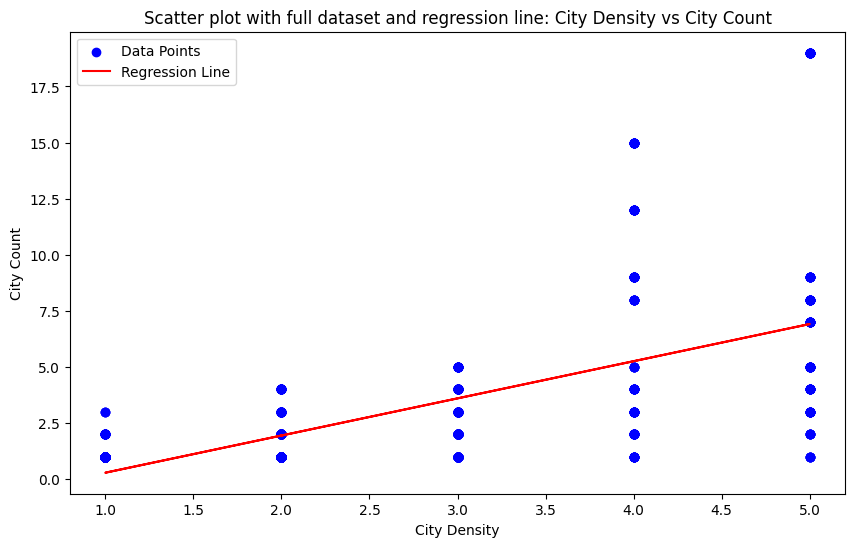

In [25]:
import matplotlib.pyplot as plt
import numpy as np

x = BK['city_density']
y = BK['city_count']

plt.figure(figsize=(10, 6))

plt.scatter(x, y, color='blue', label='Data Points')

m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, color='red', label='Regression Line')

plt.xlabel('City Density')
plt.ylabel('City Count')
plt.title('Scatter plot with full dataset and regression line: City Density vs City Count')

plt.legend()

plt.show()

#Top Cities By City Count

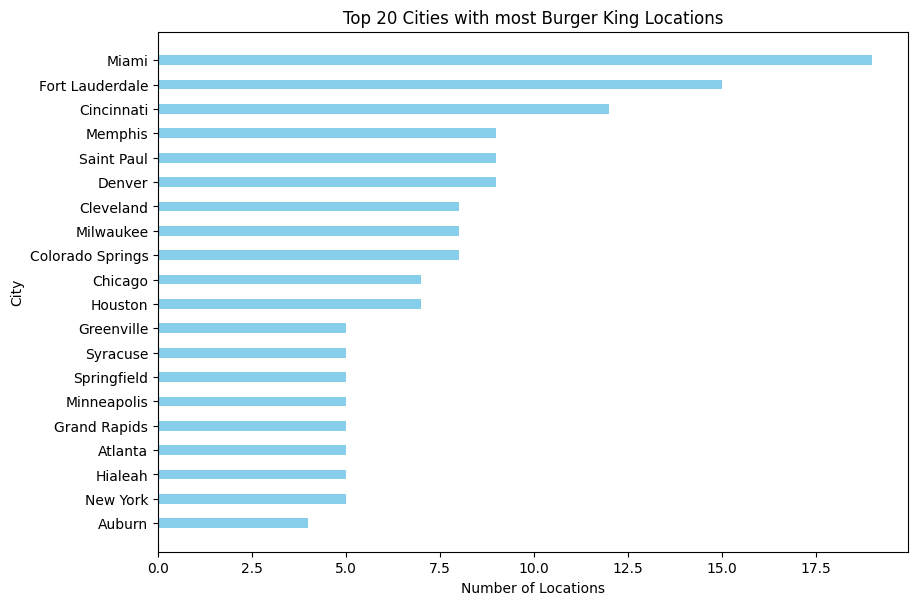

In [10]:
import matplotlib.pyplot as plt

unique_cities = BK.drop_duplicates(subset='city')

top_cities = unique_cities.nlargest(20, 'city_count')

plt.figure(figsize=(10, 8))
plt.barh(top_cities['city'], top_cities['city_count'], color='skyblue', height=0.4)

plt.subplots_adjust(left=0.2, right=0.95, top=0.7, bottom=0.05)

plt.xlabel('Number of Locations')
plt.ylabel('City')
plt.title('Top 20 Cities with most Burger King Locations')
plt.gca().invert_yaxis()
plt.show()

#Potential Burger King Locations!!
##(Based on City density)

In [11]:
city_density_threshold = 5
low_city_count_threshold = 1

result1 = BK[(BK['city_density'] >= city_density_threshold) & (BK['city_count'] <= low_city_count_threshold)]

result1

,city,latitude,longitude,Has_highway,city_count,city_density,road_proximity
2401,Kansas City,39.145320,-94.557960,0,1,5,2
2608,San Jose,37.304643,-121.861345,1,1,5,1
7713,Boston,42.360650,-71.060820,0,1,5,1
8274,Dallas,32.792190,-96.699070,0,1,5,1
9371,Detroit,42.368993,-83.138806,0,1,5,1


##(Based on Proximity to large Road)

In [12]:
road_threshold = 1
low_city_count_threshold = 1

result2 = BK[(BK['road_proximity'] <= road_threshold) & (BK['city_count'] <= low_city_count_threshold)]
result2

,city,latitude,longitude,Has_highway,city_count,city_density,road_proximity
2608,San Jose,37.304643,-121.861345,1,1,5,1
4528,Van Nuys,34.220897,-118.471622,0,1,3,1
4561,North Hollywood,34.186680,-118.413250,0,1,3,1
6716,Jersey City,40.730079,-74.040712,0,1,4,1
7713,Boston,42.360650,-71.060820,0,1,5,1
8274,Dallas,32.792190,-96.699070,0,1,5,1
8485,Culver City,34.000393,-118.394884,0,1,2,1
9371,Detroit,42.368993,-83.138806,0,1,5,1
9702,Santa Ana,33.709007,-117.859150,0,1,4,1


In [15]:
import folium
from IPython.display import display

m = folium.Map(location=[37.0902, -95.7129], zoom_start=4)

#Enter result1 for City density and result2 for road proximity
desired_rows = result1

for index, row in desired_rows.iterrows():
    folium.Marker(
        location=[row['latitude'], row['longitude']],
        icon=folium.Icon(color='blue', icon='star')
    ).add_to(m)


display(m)


In [ ]:
BK = BK.drop(columns = ["city"])

In [ ]:
BK.corr()

,latitude,longitude,Has_highway,city_density,city_count,road_proximity
latitude,1.000000,-0.046875,-0.097642,-0.168452,-0.259311,0.171369
longitude,-0.046875,1.000000,0.007738,-0.109852,0.047679,0.084231
Has_highway,-0.097642,0.007738,1.000000,-0.106801,-0.050002,0.125167
city_density,-0.168452,-0.109852,-0.106801,1.000000,0.614075,-0.876515
city_count,-0.259311,0.047679,-0.050002,0.614075,1.000000,-0.519683
road_proximity,0.171369,0.084231,0.125167,-0.876515,-0.519683,1.000000
